# Time Series — ARIMA Forecasting

- ARIMA(p,d,q): AutoRegressive + Integrated (differencing) + Moving Average error terms
- p = AR lags, d = differences for stationarity, q = MA error lags
- Dataset: AirPassengers.csv (forecasting monthly airline passengers)[https://www.kaggle.com/datasets/rakannimer/air-passengers](https://)

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("/content/AirPassengers.csv")
df

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


In [3]:
df.columns = ["Month", "Passengers"]
df["Month"] = pd.to_datetime(df["Month"])
df = df.set_index("Month")

print(df.head())
print("Shape:", df.shape)

            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121
Shape: (144, 1)


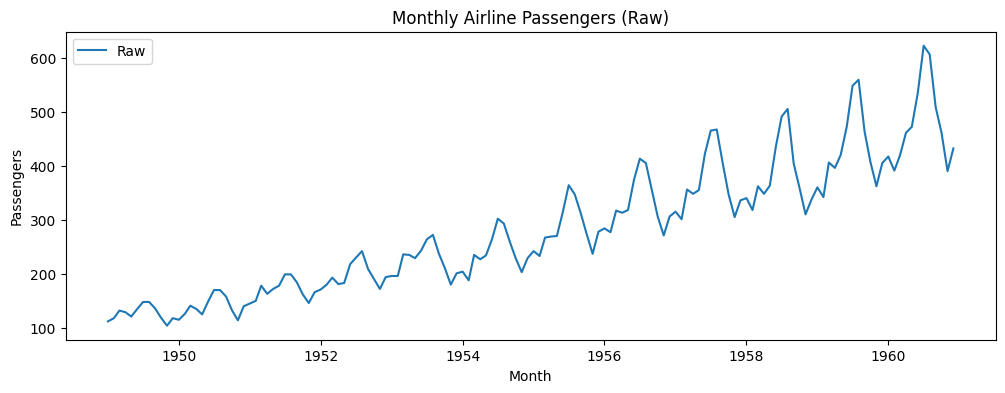

In [4]:
# Plot raw data
plt.figure(figsize=(12, 4))
plt.plot(df["Passengers"], label="Raw")
plt.title("Monthly Airline Passengers (Raw)")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.legend()
plt.show()

In [9]:
# Check stationarity (ADF test)
result = adfuller(df["Passengers"])
print("ADF Statistic:", round(result[0], 4))
print("p-value      :", round(result[1], 4))
print("Stationary   :", result[1] < 0.05)

ADF Statistic: 0.8154
p-value      : 0.9919
Stationary   : False


- ADF test checks if the series has a unit root (non-stationary trend)
- p-value < 0.05 → stationary; p-value ≥ 0.05 → non-stationary → need differencing (d ≥ 1)
- AirPassengers has a clear upward trend so expect non-stationary here

After 1st difference:
ADF Statistic: -2.8293
p-value      : 0.0542
Stationary   : False


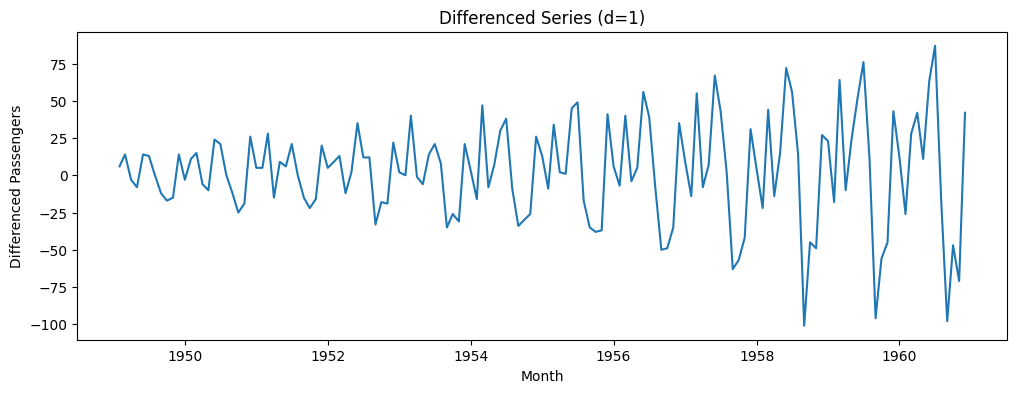

In [10]:
# Difference the series + retest

df["Passengers_diff"] = df["Passengers"].diff().dropna()

result_diff = adfuller(df["Passengers_diff"].dropna())
print("After 1st difference:")
print("ADF Statistic:", round(result_diff[0], 4))
print("p-value      :", round(result_diff[1], 4))
print("Stationary   :", result_diff[1] < 0.05)

plt.figure(figsize=(12, 4))
plt.plot(df["Passengers_diff"])
plt.title("Differenced Series (d=1)")
plt.xlabel("Month")
plt.ylabel("Differenced Passengers")
plt.show()

diff() computes xt−xt−1x_t - x_{t-1}
xt​−xt−1​ (first difference, d=1) — removes the trend
If still non-stationary after d=1, try d=2

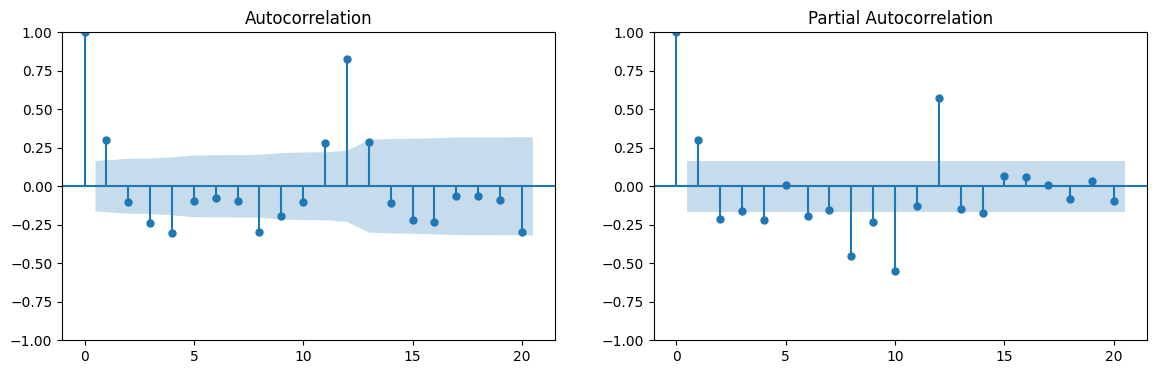

In [11]:
#  ACF and PACF plots (choose q and p)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df["Passengers_diff"].dropna(), lags=20, ax=axes[0])
plot_pacf(df["Passengers_diff"].dropna(), lags=20, ax=axes[1])
plt.show()

- ACF plot: lags where autocorrelation is significant (outside shaded band) suggest q (MA order)
- PACF plot: lags where partial autocorrelation is significant suggest p (AR order)
- Look at where both plots first cut into the shaded band to decide p and q

In [12]:
train = df["Passengers"][:-12]  # all but last 12 months
test  = df["Passengers"][-12:]  # last 12 months for evaluation
print("Train size:", len(train))
print("Test size :", len(test))

model = ARIMA(train, order=(2, 1, 2))
model_fit = model.fit()
print(model_fit.summary())

Train size: 132
Test size : 12
                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  132
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -607.782
Date:                Sat, 04 Jul 2026   AIC                           1225.563
Time:                        09:38:01   BIC                           1239.939
Sample:                    01-01-1949   HQIC                          1231.405
                         - 12-01-1959                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6660      0.024     68.561      0.000       1.618       1.714
ar.L2         -0.9294      0.022    -41.536      0.000      -0.973      -0.886
ma.L1         -1.8324

RMSE: 55.22


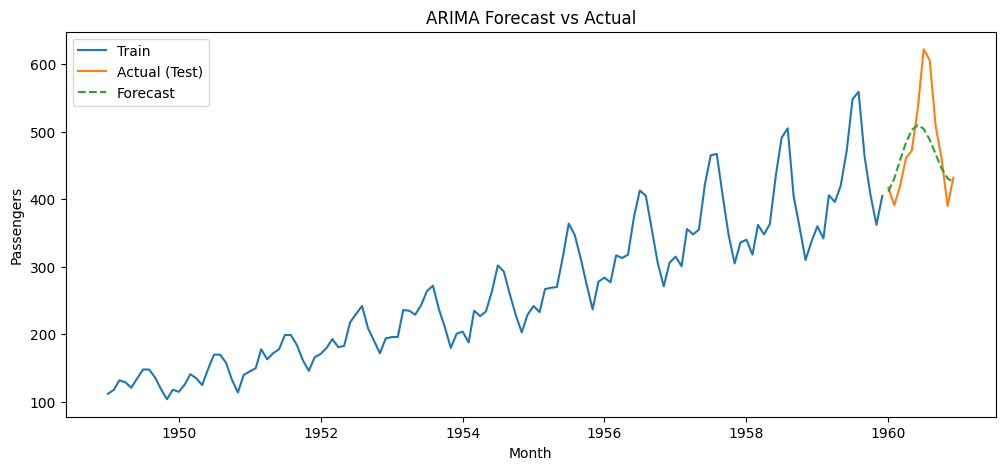

In [13]:
forecast = model_fit.forecast(steps=12)

mse = mean_squared_error(test, forecast)
rmse = np.sqrt(mse)

print("RMSE:", round(rmse, 2))

plt.figure(figsize=(12, 5))
plt.plot(train, label="Train")
plt.plot(test, label="Actual (Test)")
plt.plot(test.index, forecast, label="Forecast", linestyle="--")
plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.legend()
plt.show()

## Conclusion
- ADF test confirmed the raw series was non-stationary (upward trend) — one round of differencing (d=1) made it stationary
- ACF/PACF plots guided the choice of q (MA order) and p (AR order)
- ARIMA(p,1,q) combined past values (AR), error correction (MA), and differencing (I) to model the series
- Forecast vs actual plot shows how well the model predicted the final 12 months it never saw during training
- RMSE gives a concrete measure of forecast error in the original units (number of passengers)